## Step 1: Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df  = pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\House_price prediction\data\Housing.csv")

In [4]:
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


## Step 2: Data Understanding

In [5]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [7]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


## Step 3. Data Cleaning

In [8]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.drop_duplicates(inplace=True)

## Step 2: Exploratory Data Analysis (EDA)
### Target Variable Distribution

<function matplotlib.pyplot.show(close=None, block=None)>

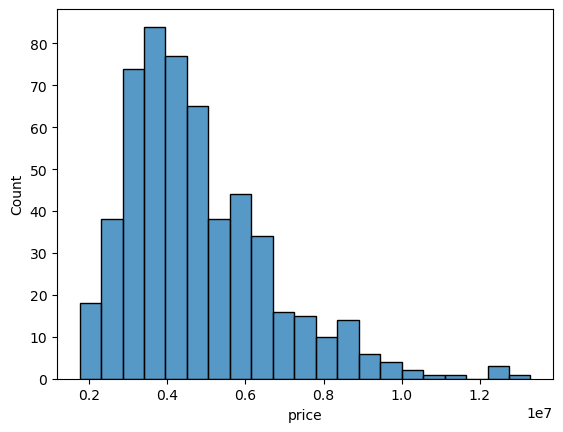

In [11]:
sns.histplot(df['price'])
plt.show

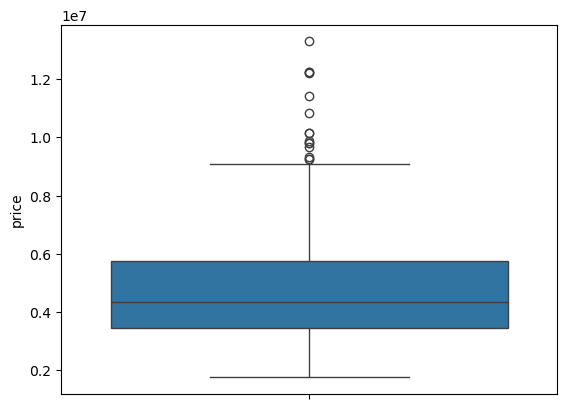

In [12]:
sns.boxplot(df['price'])
plt.show()

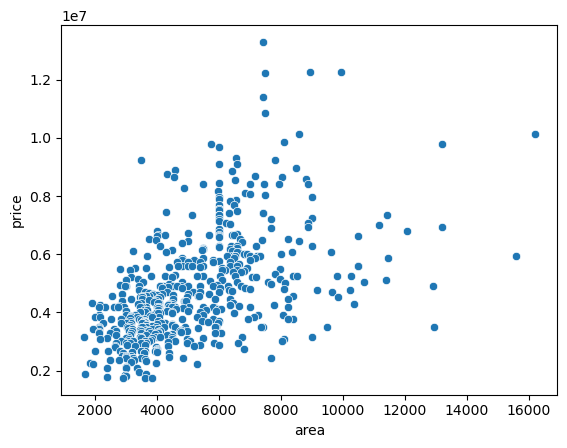

In [13]:
sns.scatterplot(
    x='area',
    y='price',
    data=df
)
plt.show()

## Correlation

In [14]:
corr = df.corr(numeric_only=True)
corr

,price,area,bedrooms,bathrooms,stories,parking
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.384394
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.352980
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,0.139270
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.177496
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.045547
parking,0.384394,0.352980,0.139270,0.177496,0.045547,1.000000


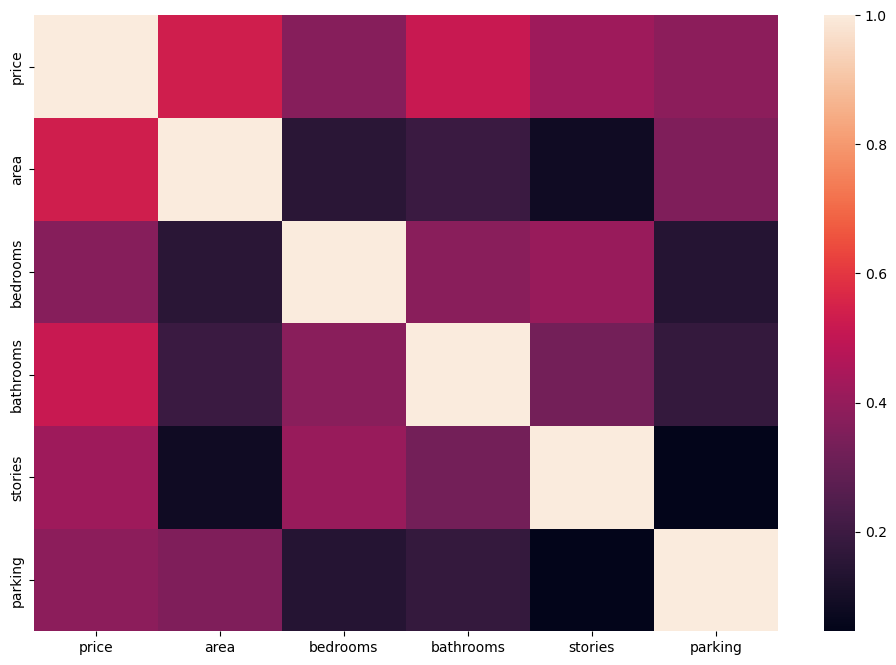

In [15]:
plt.figure(figsize=(12,8))
sns.heatmap(corr)
plt.show()

## Step 4 : Feature Selection

In [16]:
x = df[['area',
        'bedrooms',
        'bathrooms',
        'stories',
        'parking']]

y = df[['price']]

In [17]:
x

,area,bedrooms,bathrooms,stories,parking
0,7420,4,2,3,2
1,8960,4,4,4,3
2,9960,3,2,2,2
3,7500,4,2,2,3
4,7420,4,1,2,2
...,...,...,...,...,...
540,3000,2,1,1,2
541,2400,3,1,1,0
542,3620,2,1,1,0
543,2910,3,1,1,0


In [18]:
y

,price
0,13300000
1,12250000
2,12250000
3,12215000
4,11410000
...,...
540,1820000
541,1767150
542,1750000
543,1750000


## step5 : Train-Test Split

In [19]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)
print(X_train.shape)
print(X_test.shape)

(436, 5)
(109, 5)


In [20]:
train_test_split(x,y,test_size = 0.2,random_state = 42)

[     area  bedrooms  bathrooms  stories  parking
 46   6000         3          2        4        1
 93   7200         3          2        1        3
 335  3816         2          1        1        2
 412  2610         3          1        2        0
 471  3750         3          1        2        0
 ..    ...       ...        ...      ...      ...
 71   6000         4          2        4        0
 106  5450         4          2        1        0
 270  4500         3          2        3        1
 435  4040         2          1        1        0
 102  5500         3          2        4        1
 
 [436 rows x 5 columns],
      area  bedrooms  bathrooms  stories  parking
 316  5900         4          2        2        1
 77   6500         3          2        3        0
 360  4040         2          1        1        0
 90   5000         3          1        2        0
 493  3960         3          1        1        0
 ..    ...       ...        ...      ...      ...
 15   6000         4   

## Step 6: Model Training

In [21]:
from sklearn.linear_model import LinearRegression


### LinearRegression

In [22]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

### Prediction

In [23]:
prediction = model.predict(X_test)

In [24]:
print(prediction[:5])

[[6178627.50326817]
 [6370140.85865473]
 [3283148.1570249 ]
 [4226007.94816032]
 [3409685.55116741]]


## R² Score

In [66]:
from sklearn.metrics import r2_score
prediction_lr = model.predict(X_test)
score = r2_score(y_test,prediction_lr)
print(score)

0.26253874216322404


## DecisionTreeRegressor

In [67]:
from sklearn.tree import DecisionTreeRegressor
model =  DecisionTreeRegressor()
model.fit(X_train,y_train)


DecisionTreeRegressor()

In [68]:
prediction_dt = model.predict(X_test)

In [69]:
## check score 
score  = r2_score(y_test,prediction_dt)
print(score)

0.25812290199797927


### Random Forest

In [46]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train.values.ravel())

#prediction
pred_rf = rf.predict(X_test)

# check score
score_rf = r2_score(y_test, pred_rf)

print("Random Forest:", score_rf)

Random Forest: 0.48691222287234903


### KNN

In [47]:
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor()
knn.fit(X_train,y_train)

KNeighborsRegressor()

In [48]:
# prediction
prediction = knn.predict(X_test)

In [49]:
## r2_score
score_knn = r2_score(y_test,prediction)
score_knn

0.36959471404033284

In [50]:
## MAE
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, prediction)
mae

1298140.3669724772

## Support Vector Regressor(SVR)


In [51]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [52]:
# model
svr = SVR()
svr.fit(X_train_scaled,y_train.values.ravel())



SVR()

In [53]:
# prediction
pred_svr = svr.predict(
    X_test_scaled
)


In [54]:
# Evaluation

r2_svr = r2_score(
    y_test,
    pred_svr
)

mae_svr = mean_absolute_error(
    y_test,
    pred_svr
)

mse_svr = mean_squared_error(
    y_test,
    pred_svr
)

rmse_svr = np.sqrt(
    mse_svr
)

print("R2 Score =", r2_svr)
print("MAE =", mae_svr)
print("MSE =", mse_svr)
print("RMSE =", rmse_svr)

R2 Score = -0.10156189252588588
MAE = 1763886.6428081566
MSE = 5567921966485.061
RMSE = 2359644.4576429436


## Model Comparison

In [70]:
results = pd.DataFrame({
    "Model": ["Linear Regression","Decision Tree","Random Forest","KNN","SVR"],
    "R2 Score": [score_lr,score_dt,score_rf,score_knn,r2_svr]
})

print(results)

               Model  R2 Score
0  Linear Regression  0.546406
1      Decision Tree  0.262539
2      Random Forest  0.486912
3                KNN  0.369595
4                SVR -0.101562


## Best Model Find

In [71]:
best_model = results.loc[results["R2 Score"].idxmax()]

print(best_model)

Model       Linear Regression
R2 Score             0.546406
Name: 0, dtype: object


In [72]:
import pickle

pickle.dump(
    rf,
    open("best_model.pkl","wb")
)

In [73]:
import os

print(os.path.exists("best_model.pkl"))

True
